In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import ast

In [2]:
T_START = 50
GUIDANCE_WEIGHT = 0.025
THS = 0.5634

In [3]:

# Load CSV
cf_results = pd.read_csv(f"/zhome/d0/a/221493/thesis/results/diffusion_cf/{T_START}/{GUIDANCE_WEIGHT}/cf_results.csv")
cf_results

,original_path,original_prob,cf_prob,true_label,original_pred,correct,cf_pred,flip_achieved,intermediate_probs
0,CheXpert-v1.0-small/train/patient37784/study8/...,0.993187,0.125266,1,1,1,0,True,"[(50, 0.41667866706848145), (49, 0.45829921960..."
1,CheXpert-v1.0-small/train/patient46974/study3/...,0.846498,0.055786,1,1,1,0,True,"[(50, 0.19146545231342316), (49, 0.20121468603..."
2,CheXpert-v1.0-small/train/patient37415/study2/...,0.927383,0.170195,1,1,1,0,True,"[(50, 0.3057754337787628), (49, 0.295834749937..."
3,CheXpert-v1.0-small/train/patient33612/study2/...,0.981391,0.176447,1,1,1,0,True,"[(50, 0.2463492602109909), (49, 0.257581591606..."
4,CheXpert-v1.0-small/train/patient01127/study5/...,0.997201,0.194358,1,1,1,0,True,"[(50, 0.22858288884162903), (49, 0.25549891591..."
...,...,...,...,...,...,...,...,...,...
75,CheXpert-v1.0-small/train/patient36075/study3/...,0.519186,0.963546,1,0,0,1,True,"[(50, 0.25397124886512756), (49, 0.27587860822..."
76,CheXpert-v1.0-small/train/patient46454/study2/...,0.447510,0.987836,1,0,0,1,True,"[(50, 0.3342212736606598), (49, 0.345979720354..."
77,CheXpert-v1.0-small/train/patient03979/study1/...,0.078700,0.951988,1,0,0,1,True,"[(50, 0.2691320776939392), (49, 0.298608422279..."
78,CheXpert-v1.0-small/train/patient29521/study3/...,0.032720,0.863558,1,0,0,1,True,"[(50, 0.21103255450725555), (49, 0.22294628620..."


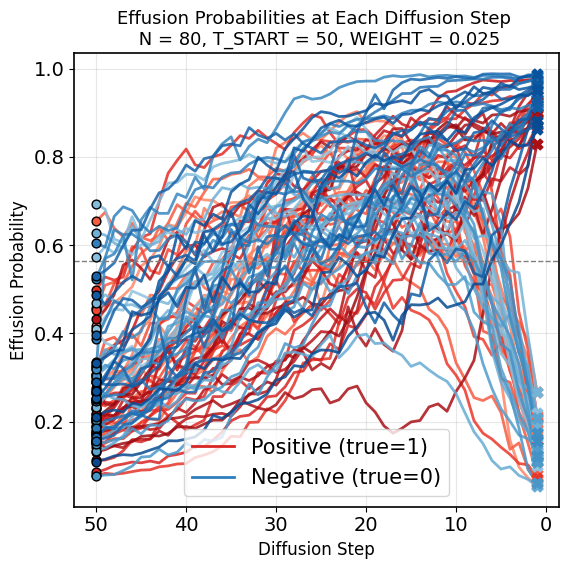

In [4]:
## INDIVIDUAL PLOT OF PROBABILITIES AT EACH STEP

import ast
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
plt.rcParams.update({
    'font.size': 17,
    'axes.linewidth': 1.2,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 15,
})


plt.figure(figsize=(6, 6))

# Split by class for nicer color control
pos_rows = cf_results[cf_results['correct'] == 1]
neg_rows = cf_results[cf_results['correct'] == 0]

# Create color gradients
pos_colors = cm.Reds(np.linspace(0.4, 0.9, len(pos_rows)))
neg_colors = cm.Blues(np.linspace(0.4, 0.9, len(neg_rows)))

# ── Plot positives (red shades) ─────────────────────────────────────────
for color, (_, row) in zip(pos_colors, pos_rows.iterrows()):
    intermediate_probs = ast.literal_eval(row['intermediate_probs'])
    
    steps = [step[0] for step in intermediate_probs]
    probs = [step[1] for step in intermediate_probs]

    plt.plot(
        steps, probs,
        color=color,
        alpha=0.85,
        linewidth=2
    )

    # highlight start + end
    plt.scatter(steps[0], probs[0], color=color, s=40, edgecolor='black', zorder=3)
    plt.scatter(steps[-1], probs[-1], color=color, s=60, marker='X', zorder=3)

# ── Plot negatives (blue shades) ────────────────────────────────────────
for color, (_, row) in zip(neg_colors, neg_rows.iterrows()):
    intermediate_probs = ast.literal_eval(row['intermediate_probs'])
    
    steps = [step[0] for step in intermediate_probs]
    probs = [step[1] for step in intermediate_probs]

    plt.plot(
        steps, probs,
        color=color,
        alpha=0.85,
        linewidth=2
    )

    plt.scatter(steps[0], probs[0], color=color, s=40, edgecolor='black', zorder=3)
    plt.scatter(steps[-1], probs[-1], color=color, s=60, marker='X', zorder=3)

# ── Styling ─────────────────────────────────────────────────────────────
plt.xlabel("Diffusion Step", fontsize=12)
plt.ylabel("Effusion Probability", fontsize=12)
plt.title(f"Effusion Probabilities at Each Diffusion Step \n N = {cf_results.shape[0]}, T_START = {T_START}, WEIGHT = {GUIDANCE_WEIGHT}", fontsize=13)

# pLOT LINE AT THS
plt.axhline(THS, color='gray', linestyle='--', linewidth=1, label=f'Threshold = {THS:.2f}')

plt.gca().invert_xaxis()
plt.grid(alpha=0.3)

# Cleaner legend (manual)
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=cm.Reds(0.7), lw=2, label='Positive (true=1)'),
    Line2D([0], [0], color=cm.Blues(0.7), lw=2, label='Negative (true=0)'),
]
plt.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

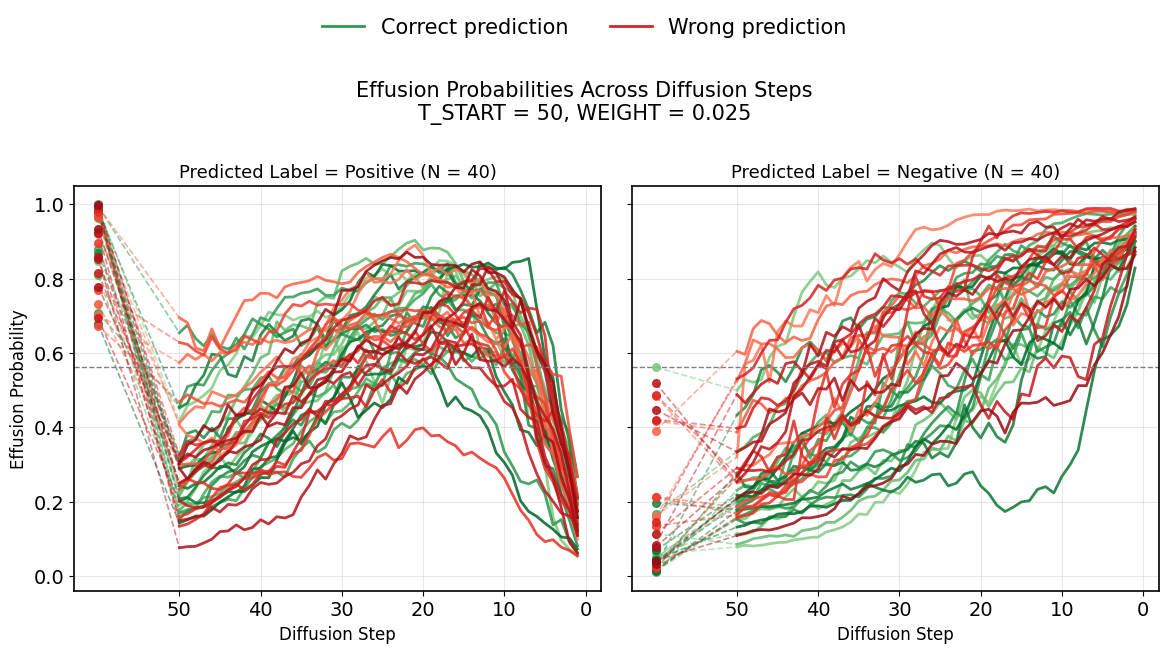

In [6]:
import ast
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D

plt.rcParams.update({
    'font.size': 17,
    'axes.linewidth': 1.2,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 15,
})

# ──────────────────────────────────────────────────────────────────────
# Split dataframe by ground-truth class
# ──────────────────────────────────────────────────────────────────────
pos_rows = cf_results[cf_results['original_pred'] == 1]
neg_rows = cf_results[cf_results['original_pred'] == 0]

# ──────────────────────────────────────────────────────────────────────
# Helper: parse trajectories and compute per-step mean
# ──────────────────────────────────────────────────────────────────────
ORIG_X = T_START + 10  # sits just left of the trajectory start

def plot_trajectories(ax, rows, title):
    n_correct = (rows['correct'] == True).sum()
    n_wrong   = (rows['correct'] == False).sum()
    green_colors = cm.Greens(np.linspace(0.45, 0.9, max(1, n_correct)))
    red_colors   = cm.Reds(  np.linspace(0.45, 0.9, max(1, n_wrong)))
    green_idx = red_idx = 0

    for _, row in rows.iterrows():
        intermediate_probs = ast.literal_eval(row['intermediate_probs'])
        steps = [s[0] for s in intermediate_probs]
        probs = [s[1] for s in intermediate_probs]

        if row['correct']:
            color = green_colors[green_idx]; green_idx += 1
        else:
            color = red_colors[red_idx];     red_idx   += 1

        # solid trajectory
        ax.plot(steps, probs, color=color, alpha=0.85, linewidth=2)

        # dashed bridge from original_prob → first noisy step, dont show x tick for this
        ax.plot([ORIG_X, steps[0]], [row['original_prob'], probs[0]],
                color=color, alpha=0.5, linewidth=1.2, linestyle='--')

        # dot at ORIG_X = clean image probability (before noising)
        ax.scatter(ORIG_X, row['original_prob'],
                   color=color, s=30, alpha=0.85, zorder=5)

    ax.axhline(THS, color='gray', linestyle='--', linewidth=1)
    ax.invert_xaxis()
    ax.grid(alpha=0.3)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Diffusion Step", fontsize=12)
    
    # We create a range from 0 up to T_START with a step of 10
    tick_values = np.arange(0, T_START + 1, 10)
    ax.set_xticks(tick_values)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

plot_trajectories(axes[0], pos_rows,
                  f"Predicted Label = Positive (N = {len(pos_rows)})")
axes[0].set_ylabel("Effusion Probability", fontsize=12)

plot_trajectories(axes[1], neg_rows,
                  f"Predicted Label = Negative (N = {len(neg_rows)})")

legend_elements = [
    Line2D([0], [0], color=cm.Greens(0.7), lw=2, label='Correct prediction'),
    Line2D([0], [0], color=cm.Reds(0.7),   lw=2, label='Wrong prediction'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2,
           frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.suptitle(
    f"Effusion Probabilities Across Diffusion Steps\n"
    f"T_START = {T_START}, WEIGHT = {GUIDANCE_WEIGHT}",
    fontsize=15
)
plt.tight_layout()
plt.show()


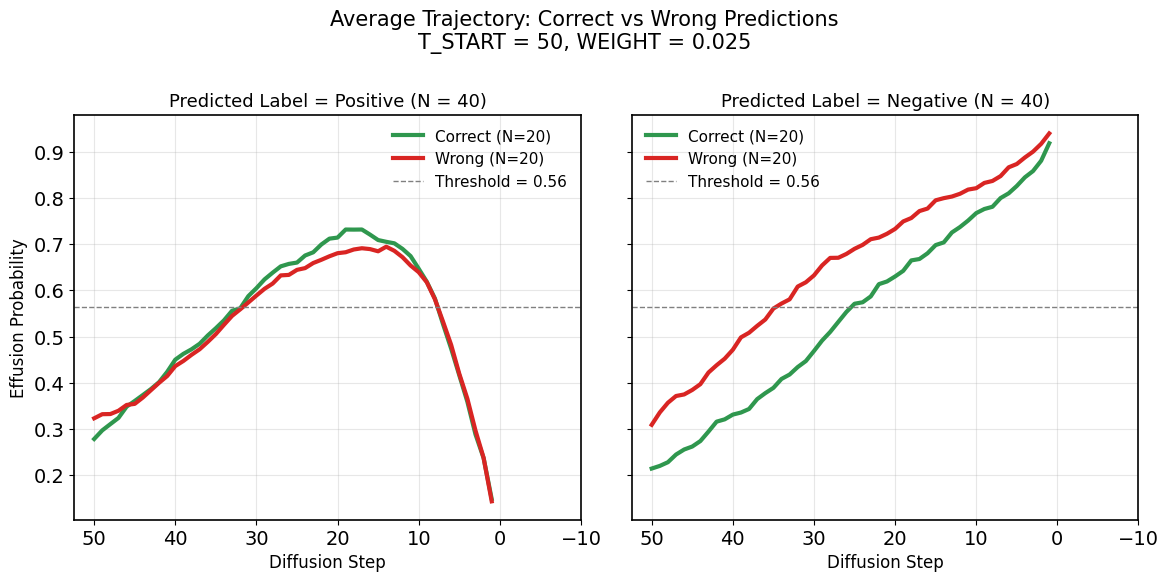

In [9]:
# ══════════════════════════════════════════════════════════════════════
# PLOT 2 — Average trajectory: correct vs wrong, both classes
# ══════════════════════════════════════════════════════════════════════

mean_trajectory = lambda df: (
    np.array([step[0] for step in ast.literal_eval(df.iloc[0]['intermediate_probs'])]),
    np.mean([np.array([step[1] for step in ast.literal_eval(row['intermediate_probs'])]) for _, row in df.iterrows()], axis=0)
) if len(df) > 0 else (None, None)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

for ax, rows, label in [
    (axes[0], pos_rows, "Positive"),
    (axes[1], neg_rows, "Negative"),
]:
    correct = rows[rows['correct'] == True]
    wrong   = rows[rows['correct'] == False]

    steps_c, mean_c = mean_trajectory(correct)
    steps_w, mean_w = mean_trajectory(wrong)

    if steps_c is not None:
        ax.plot(steps_c, mean_c, color=cm.Greens(0.7), linewidth=3,
                label=f'Correct (N={len(correct)})')
    if steps_w is not None:
        ax.plot(steps_w, mean_w, color=cm.Reds(0.7), linewidth=3,
                label=f'Wrong (N={len(wrong)})')

    ax.axhline(THS, color='gray', linestyle='--', linewidth=1,
               label=f'Threshold = {THS:.2f}')
    ax.invert_xaxis()
    ax.set_xticks([t for t in ax.get_xticks() if abs(t - ORIG_X) > 1])
    ax.grid(alpha=0.3)
    ax.set_title(f"Predicted Label = {label} (N = {len(rows)})", fontsize=13)
    ax.set_xlabel("Diffusion Step", fontsize=12)
    ax.legend(frameon=False, fontsize=11)

axes[0].set_ylabel("Effusion Probability", fontsize=12)

fig.suptitle(
    f"Average Trajectory: Correct vs Wrong Predictions\n"
    f"T_START = {T_START}, WEIGHT = {GUIDANCE_WEIGHT}",
    fontsize=15
)
plt.tight_layout()
plt.show()

In [ ]:
# Plot as a confusion matriz setup - TP, FP, TN, FN
